In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [9]:
df = pd.read_csv("data/kc_house_data_original.csv")

print(df.head())
print(df.info())
print(df.describe())
print(df.columns)

           id             date     price  bedrooms  bathrooms  sqft_living  \
0  7129300520  20141013T000000  221900.0         3       1.00         1180   
1  6414100192  20141209T000000  538000.0         3       2.25         2570   
2  5631500400  20150225T000000  180000.0         2       1.00          770   
3  2487200875  20141209T000000  604000.0         4       3.00         1960   
4  1954400510  20150218T000000  510000.0         3       2.00         1680   

   sqft_lot  floors  waterfront  view  condition  grade  sqft_above  \
0      5650     1.0           0     0          3      7        1180   
1      7242     2.0           0     0          3      7        2170   
2     10000     1.0           0     0          3      6         770   
3      5000     1.0           0     0          5      7        1050   
4      8080     1.0           0     0          3      8        1680   

   sqft_basement  yr_built  yr_renovated  zipcode      lat     long  \
0              0      1955       

In [10]:
df["date"] = pd.to_datetime(df["date"])
df["month_sold"] = df["date"].dt.to_period("M").astype(str)

df[["date", "month_sold"]].head()

,date,month_sold
0,2014-10-13,2014-10
1,2014-12-09,2014-12
2,2015-02-25,2015-02
3,2014-12-09,2014-12
4,2015-02-18,2015-02


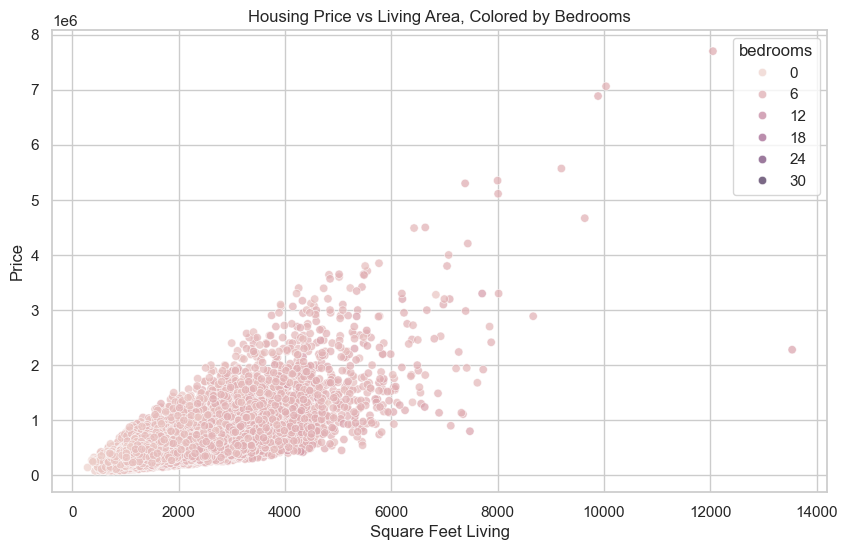

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="sqft_living",
    y="price",
    hue="bedrooms",
    alpha=0.7
)
plt.title("Housing Price vs Living Area, Colored by Bedrooms")
plt.xlabel("Square Feet Living")
plt.ylabel("Price")
plt.show()

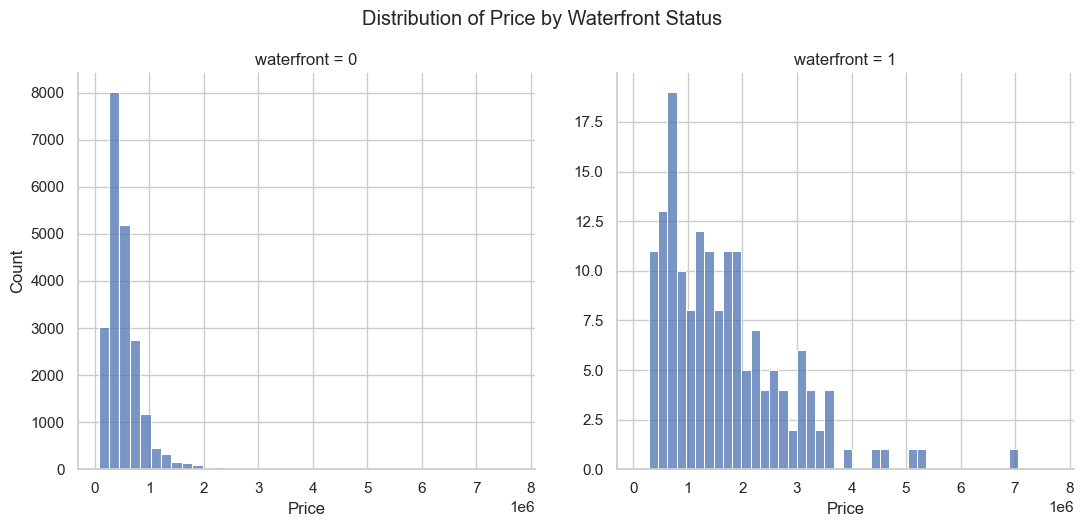

In [16]:
g = sns.FacetGrid(df, col="waterfront", height=5, aspect=1.1, sharex=True, sharey=False)
g.map_dataframe(sns.histplot, x="price", bins=40)
g.set_axis_labels("Price", "Count")
g.fig.suptitle("Distribution of Price by Waterfront Status", y=1.05)
plt.show()

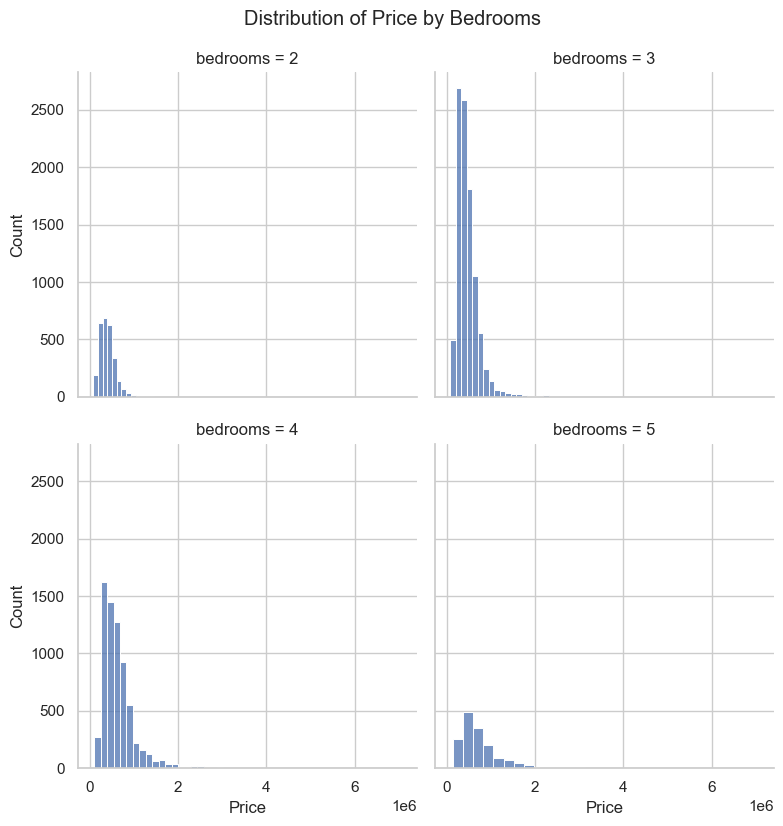

In [17]:
bedroom_subset = df[df["bedrooms"].isin([2, 3, 4, 5])]

g = sns.FacetGrid(bedroom_subset, col="bedrooms", col_wrap=2, height=4)
g.map_dataframe(sns.histplot, x="price", bins=30)
g.set_axis_labels("Price", "Count")
g.fig.suptitle("Distribution of Price by Bedrooms", y=1.03)
plt.show()

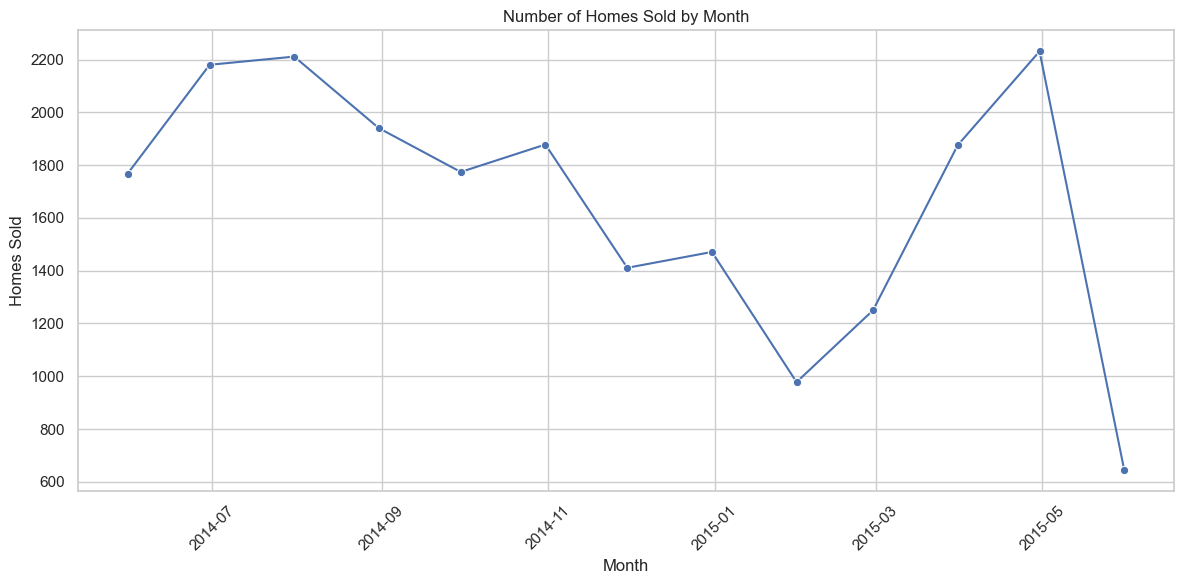

In [19]:
sales_by_month = df.resample("ME", on="date").size().reset_index(name="homes_sold")

plt.figure(figsize=(12, 6))
sns.lineplot(data=sales_by_month, x="date", y="homes_sold", marker="o")
plt.title("Number of Homes Sold by Month")
plt.xlabel("Month")
plt.ylabel("Homes Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

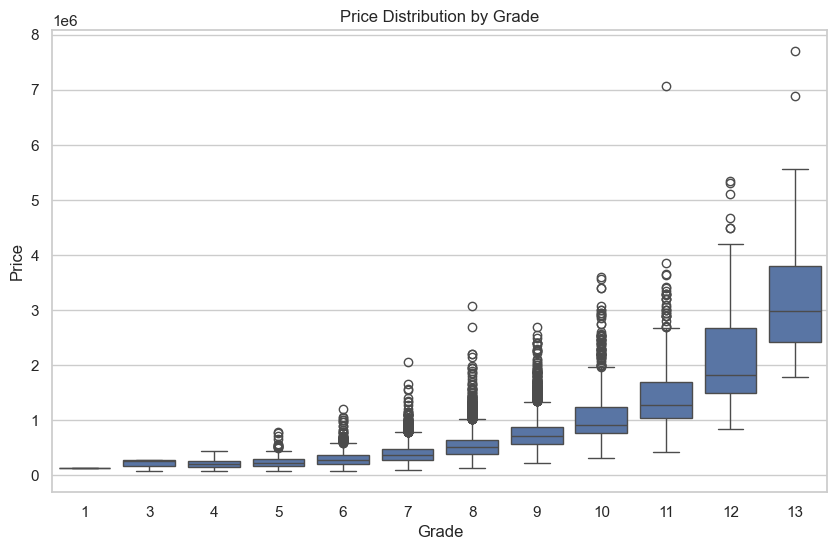

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="grade", y="price")
plt.title("Price Distribution by Grade")
plt.xlabel("Grade")
plt.ylabel("Price")
plt.show()